# Mask R-CNN Fine-Tuning on LVIS Dataset

This notebook fine-tunes a **Mask R-CNN (ResNet-50 + FPN)** model on a 16K-image subset of the [LVIS dataset](https://www.lvisdataset.org/) for instance segmentation. It covers three stages:

1. **Training** — Dataset preparation, model definition, and training loop
2. **Inference** — Loading saved weights and running predictions on a test image
3. **Evaluation** — Computing Mean IoU (mIoU) and rare-class detection accuracy

## Part 1: Training

In [19]:
pip install -r requirements.txt

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_

### 1.1 Dataset Extraction & Exploration

Extracts the LVIS 16K dataset from a zip archive, explores the directory structure, and verifies that images and annotation files are present.

In [10]:
import zipfile

zip_path = "lvis_16k_dataset.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    print(root)
    for d in dirs:
        print("  📁", d)
    for f in files[:5]:
        print("  📄", f)

dataset
  📁 lvis_16k_dataset
dataset/lvis_16k_dataset
  📁 images
  📄 annotations.json
dataset/lvis_16k_dataset/images
  📄 000000000049.jpg
  📄 000000000192.jpg
  📄 000000000196.jpg
  📄 000000000257.jpg
  📄 000000000357.jpg


In [12]:
IMAGE_DIR = "dataset/lvis_16k_dataset/images"
ANNOTATION_FILE = "dataset/lvis_16k_dataset/annotations.json"

In [13]:
import os

print("Images count:", len(os.listdir(IMAGE_DIR)))
print("Annotation file exists:", os.path.exists(ANNOTATION_FILE))

Images count: 15744
Annotation file exists: True


### 1.2 Load & Inspect Annotations

Loads the COCO-format annotation file using `pycocotools`, prints dataset statistics, and visualizes random samples with bounding boxes, category labels, and instance segmentation masks overlaid.

In [14]:
  from pycocotools.coco import COCO

  coco = COCO(ANNOTATION_FILE)

  print("Total Images:", len(coco.imgs))
  print("Total Annotations:", len(coco.anns))
  print("Categories:", coco.cats)

loading annotations into memory...
Done (t=3.17s)
creating index...
index created!
Total Images: 15744
Total Annotations: 211677
Categories: {1: {'name': 'aerosol_can', 'instance_count': 109, 'def': 'a dispenser that holds a substance under pressure', 'synonyms': ['aerosol_can', 'spray_can'], 'image_count': 64, 'id': 1, 'frequency': 'c', 'synset': 'aerosol.n.02'}, 2: {'name': 'air_conditioner', 'instance_count': 1081, 'def': 'a machine that keeps air cool and dry', 'synonyms': ['air_conditioner'], 'image_count': 364, 'id': 2, 'frequency': 'f', 'synset': 'air_conditioner.n.01'}, 3: {'name': 'airplane', 'instance_count': 3720, 'def': 'an aircraft that has a fixed wing and is powered by propellers or jets', 'synonyms': ['airplane', 'aeroplane'], 'image_count': 1911, 'id': 3, 'frequency': 'f', 'synset': 'airplane.n.01'}, 4: {'name': 'alarm_clock', 'instance_count': 158, 'def': 'a clock that wakes a sleeper at some preset time', 'synonyms': ['alarm_clock'], 'image_count': 149, 'id': 4, 'fre

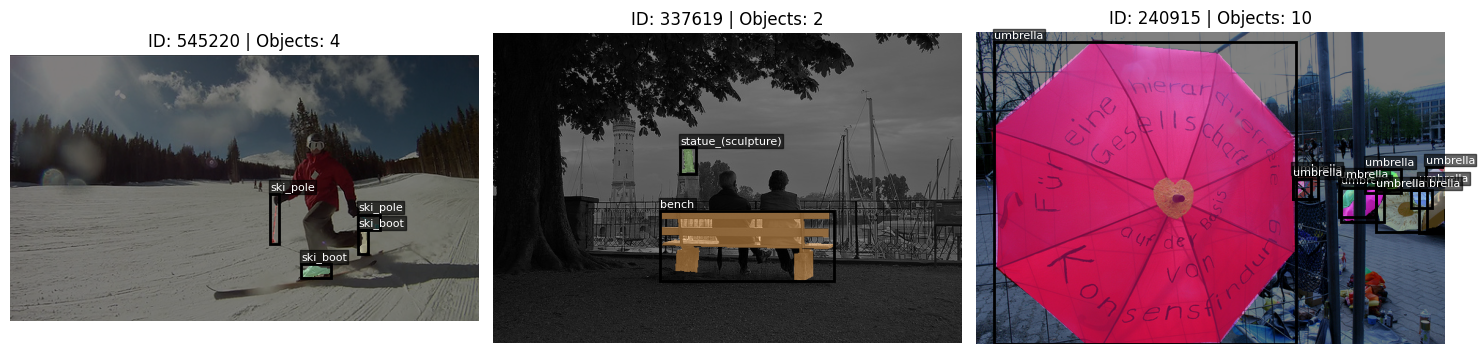

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

num_samples = 3

plt.figure(figsize=(15,5))

img_ids = list(coco.imgs.keys())

for i in range(num_samples):
    img_id = random.choice(img_ids)

    img_info = coco.loadImgs(img_id)[0]
    img_path = f"{IMAGE_DIR}/{img_info['file_name']}"

    img = cv2.imread(img_path)

    if img is None:
        print(f"Image not found: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    plt.subplot(1, num_samples, i+1)
    plt.imshow(img)

    colored_mask = np.zeros((img.shape[0], img.shape[1], 3))

    for ann in anns:
        x, y, w, h = ann['bbox']
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
        plt.gca().add_patch(rect)

        category_id = ann['category_id']
        category_name = coco.cats[category_id]['name']

        plt.text(
            x, y - 5,
            category_name,
            color='white',
            fontsize=8,
            bbox=dict(facecolor='black', alpha=0.6, pad=1)
        )

        try:
            mask = coco.annToMask(ann)

            color = np.random.rand(3)
            for c in range(3):
                colored_mask[:, :, c] += mask * color[c]

        except Exception as e:
            print(f"Mask error in image {img_id}: {e}")

    colored_mask = np.clip(colored_mask, 0, 1)

    plt.imshow(colored_mask, alpha=0.5)

    plt.title(f"ID: {img_id} | Objects: {len(anns)}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 1.3 Custom PyTorch Dataset & DataLoader

Implements `CustomCocoDataset`, a PyTorch `Dataset` that loads images and their COCO-format annotations (bounding boxes, category labels, and instance segmentation masks). A `DataLoader` wraps the dataset with batching and shuffling.

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2

class CustomCocoDataset(Dataset):
    def __init__(self, image_dir, annotation_file):
        self.image_dir = image_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        img_id = self.ids[index]

        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info['file_name']

        img = cv2.imread(f"{self.image_dir}/{path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        masks = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])

            mask = self.coco.annToMask(ann)
            masks.append(mask)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([img_id])
        }

        img = torch.as_tensor(img, dtype=torch.float32) / 255.0
        img = img.permute(2, 0, 1)

        return img, target

    def __len__(self):
        return len(self.ids)

In [22]:
from torch.utils.data import DataLoader

dataset = CustomCocoDataset(IMAGE_DIR, ANNOTATION_FILE)

data_loader = DataLoader(
    dataset,
    batch_size = 4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

loading annotations into memory...
Done (t=3.25s)
creating index...
index created!


### 1.4 Model Architecture

Defines a function that loads a **pretrained Mask R-CNN (ResNet-50 + FPN)** backbone and replaces both the box predictor and mask predictor heads to match the number of LVIS classes. Initializes the model, selects the compute device (GPU/CPU), and sets up the Adam optimizer.

In [ ]:
import torchvision

def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = \
        torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features, num_classes
        )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = \
        torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
            in_features_mask, 256, num_classes
        )

    return model

In [ ]:
num_classes = len(coco.cats) + 1
model = get_model(num_classes)

/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/venv/main/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:03<00:00, 54.8MB/s] 


In [25]:
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### 1.5 Training

Checks GPU availability, then trains the model for 5 epochs with a progress bar showing batch and average loss.

In [26]:
!nvidia-smi

Thu Apr  2 23:00:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:05:00.0 Off |                  N/A |
|  0%   55C    P2            123W /  350W |     522MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    pbar = tqdm(data_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)

    for images, targets in pbar:

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if any(len(t["boxes"]) == 0 for t in targets):
            continue

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        avg_loss = total_loss / (pbar.n + 1)

        pbar.set_postfix({
            "Batch Loss": f"{losses.item():.3f}",
            "Avg Loss": f"{avg_loss:.3f}"
        })

    print(f"\nEpoch [{epoch+1}/{num_epochs}] → Total Loss: {total_loss:.4f}")

Epoch [1/5]: 100%|██████████| 3936/3936 [27:57<00:00,  2.35it/s, Batch Loss=1.546, Avg Loss=1.784]



Epoch [1/5] → Total Loss: 7020.0944


Epoch [2/5]: 100%|██████████| 3936/3936 [28:07<00:00,  2.33it/s, Batch Loss=1.770, Avg Loss=1.465]



Epoch [2/5] → Total Loss: 5767.7982


Epoch [3/5]: 100%|██████████| 3936/3936 [28:10<00:00,  2.33it/s, Batch Loss=1.281, Avg Loss=1.348]



Epoch [3/5] → Total Loss: 5304.9699


Epoch [4/5]: 100%|██████████| 3936/3936 [28:17<00:00,  2.32it/s, Batch Loss=1.730, Avg Loss=1.259]



Epoch [4/5] → Total Loss: 4954.4728


Epoch [5/5]: 100%|██████████| 3936/3936 [28:22<00:00,  2.31it/s, Batch Loss=1.313, Avg Loss=1.188]


Epoch [5/5] → Total Loss: 4677.0489


### 1.6 Save Trained Model

Saves the trained model weights to disk as `mask_rcnn_final.pth`.

In [29]:
torch.save(model.state_dict(), "mask_rcnn_final.pth")

---

# Part 2: Inference on a Test Image

This section loads the saved Mask R-CNN weights, runs inference on a single test image, and visualizes the predicted bounding boxes, labels, and instance masks.

### 2.1 Load Trained Model

Re-initializes the COCO API, rebuilds the model architecture (with `pretrained=False`), loads the saved weights, and sets the model to evaluation mode.

In [2]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 151.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 152.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 145.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]on]
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pycocotools.coco import COCO

ANNOTATION_FILE = "lvis_16k_dataset/annotations.json"
coco = COCO(ANNOTATION_FILE)

loading annotations into memory...
Done (t=2.16s)
creating index...
index created!


In [2]:
import torchvision

def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = \
        torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features, num_classes
        )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = \
        torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
            in_features_mask, 256, num_classes
        )

    return model

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cpu')

In [ ]:
num_classes = len(coco.cats) + 1

model = get_model(num_classes)

model.load_state_dict(torch.load("mask_rcnn_final.pth", map_location=device))
model.to(device)
model.eval()

c:\Users\Bhavya Patel\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Bhavya Patel\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Bhavya Patel/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
 67%|██████▋   | 65.6M/97.8M [00:01<00:00, 36.6MB/s]

### 2.2 Load & Preprocess Test Image

Reads a test image, converts it from BGR to RGB, normalizes pixel values to `[0, 1]`, and converts it to a PyTorch tensor in `(C, H, W)` format.

In [ ]:
import cv2

image_path = "test.jpg"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_tensor = torch.as_tensor(img, dtype=torch.float32) / 255.0
img_tensor = img_tensor.permute(2, 0, 1)

### 2.3 Run Inference & Filter Predictions

Runs the model in evaluation mode on the test image, extracts predicted boxes, labels, scores, and masks, then filters them by a confidence threshold.

In [19]:
with torch.no_grad():
    prediction = model([img_tensor.to(device)])

In [20]:
pred = prediction[0]

boxes = pred["boxes"].cpu().numpy()
labels = pred["labels"].cpu().numpy()
scores = pred["scores"].cpu().numpy()
masks = pred["masks"].cpu().numpy()

In [21]:
threshold = 0.5

valid = scores > threshold

boxes = boxes[valid]
labels = labels[valid]
scores = scores[valid]
masks = masks[valid]

### 2.4 Visualize Predictions

Maps predicted category IDs to human-readable names and renders bounding boxes, labels, confidence scores, and instance masks on the test image.

In [22]:
id_to_name = {v["id"]: v["name"] for v in coco.cats.values()}

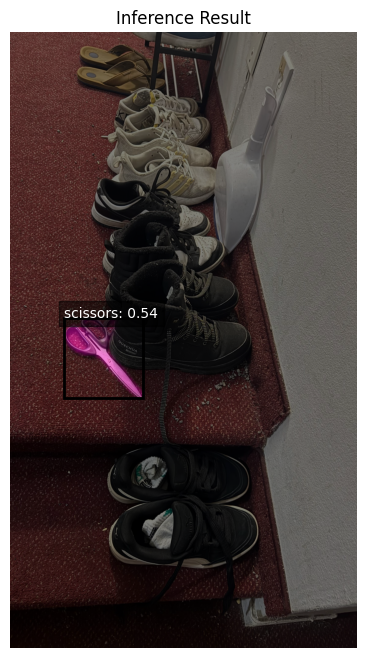

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))
plt.imshow(img)

colored_mask = np.zeros((img.shape[0], img.shape[1], 3))

for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    label = labels[i]
    score = scores[i]

    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                         fill=False, linewidth=2)
    plt.gca().add_patch(rect)

    name = id_to_name.get(label, str(label))
    plt.text(x1, y1-5, f"{name}: {score:.2f}",
             color='white',
             bbox=dict(facecolor='black', alpha=0.5))

    mask = masks[i, 0]
    color = np.random.rand(3)

    for c in range(3):
        colored_mask[:, :, c] += mask * color[c]

colored_mask = np.clip(colored_mask, 0, 1)

plt.imshow(colored_mask, alpha=0.5)
plt.axis("off")
plt.title("Inference Result")
plt.show()

---

# Part 3: Model Evaluation

This section evaluates the trained Mask R-CNN model on the dataset using two metrics:
- **Mean IoU (mIoU)** — measures segmentation mask quality
- **Rare class mAP** — measures detection accuracy on under-represented categories

### 3.1 Evaluation Dataset Setup

Re-initializes the COCO API, dataset class, and loads the trained model for evaluation.

In [3]:
from pycocotools.coco import COCO

ANNOTATION_FILE = "dataset/lvis_16k_dataset/annotations.json"
IMAGE_DIR = "dataset/lvis_16k_dataset/images"

coco = COCO(ANNOTATION_FILE)

loading annotations into memory...
Done (t=1.95s)
creating index...
index created!


In [4]:
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset

class CustomCocoDataset(Dataset):
    def __init__(self, image_dir, annotation_file):
        self.image_dir = image_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        img_id = self.ids[index]

        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info['file_name']

        img = cv2.imread(f"{self.image_dir}/{path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        masks = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x+w, y+h])
            labels.append(ann['category_id'])

            mask = self.coco.annToMask(ann)
            masks.append(mask)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([img_id])
        }

        img = torch.as_tensor(img, dtype=torch.float32) / 255.0
        img = img.permute(2, 0, 1)

        return img, target

    def __len__(self):
        return len(self.ids)

In [5]:
dataset = CustomCocoDataset(IMAGE_DIR, ANNOTATION_FILE)

loading annotations into memory...
Done (t=2.00s)
creating index...
index created!


### 3.2 Mean IoU (mIoU)

Defines a **mask IoU** function and an evaluation routine that compares predicted instance masks against ground-truth masks. Mean IoU is computed over the first 50 images as a segmentation quality metric.

In [6]:
def mask_iou(mask1, mask2):
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)

    intersection = (mask1 & mask2).sum()
    union = (mask1 | mask2).sum()

    return intersection / union if union > 0 else 0

In [7]:
def evaluate_miou(model, dataset, idx):
    model.eval()
    img, target = dataset[idx]

    with torch.no_grad():
        pred = model([img.to(device)])[0]

    gt_masks = target["masks"].numpy()
    pred_masks = pred["masks"].cpu().numpy()

    scores = pred["scores"].cpu().numpy()
    pred_masks = pred_masks[scores > 0.2]

    ious = []

    for gt in gt_masks:
        best_iou = 0
        for pm in pred_masks:
            iou = mask_iou(gt, pm[0] > 0.2)
            best_iou = max(best_iou, iou)
        ious.append(best_iou)

    return np.mean(ious) if len(ious) > 0 else 0

In [10]:
import torchvision

def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = \
        torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features, num_classes
        )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = \
        torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
            in_features_mask, 256, num_classes
        )

    return model

In [12]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
num_classes = len(coco.cats) + 1

model = get_model(num_classes)

model.load_state_dict(torch.load("mask_rcnn_final.pth", map_location=device))
model.to(device)
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

In [14]:
ious = []

for i in range(50):
    ious.append(evaluate_miou(model, dataset, i))

print("mIoU:", np.mean(ious))

mIoU: 0.4578658481986475


### 3.3 Rare Class Performance

Evaluates how well the model detects **rare categories** (classes with fewer than 100 training annotations). Computes a simple accuracy metric (mAP-rare) by checking if predicted labels match ground-truth labels for rare classes.

In [15]:
def evaluate_rare(model, dataset, idx, rare_classes):
    model.eval()
    img, target = dataset[idx]

    with torch.no_grad():
        pred = model([img.to(device)])[0]

    gt_labels = target["labels"].cpu().numpy()
    pred_labels = pred["labels"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()

    pred_labels = pred_labels[scores > 0.2]

    gt_rare = [l for l in gt_labels if l in rare_classes]
    pred_rare = [l for l in pred_labels if l in rare_classes]

    if len(gt_rare) == 0:
        return None

    correct = 0

    for gt in gt_rare:
        if gt in pred_rare:
            correct += 1

    return correct / max(len(gt_rare), 1)

In [16]:
from collections import Counter

counts = Counter([ann["category_id"] for ann in coco.anns.values()])
rare_classes = [k for k, v in counts.items() if v < 100]

results = []

for i in range(min(50, len(dataset))):
    r = evaluate_rare(model, dataset, i, rare_classes)
    if r is not None:
        results.append(r)

map_rare = np.mean(results)
print("mAP (rare):", map_rare)

mAP (rare): 0.17167919799498743


### Finalizing the metrics

In [18]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [20]:
import numpy as np
import pandas as pd
import time
from collections import Counter

# ----------------------------
# IoU function (for boxes)
# ----------------------------
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter
    return inter / union if union > 0 else 0


# ----------------------------
# Category grouping
# ----------------------------
counts = Counter([ann["category_id"] for ann in coco.anns.values()])

rare_classes = [k for k, v in counts.items() if v < 50]
common_classes = [k for k, v in counts.items() if 50 <= v < 200]
frequent_classes = [k for k, v in counts.items() if v >= 200]


# ----------------------------
# Evaluation function (IoU + label)
# ----------------------------
def evaluate_group(model, dataset, idx, class_group):
    model.eval()
    img, target = dataset[idx]

    with torch.no_grad():
        pred = model([img.to(device)])[0]

    gt_boxes = target["boxes"].cpu().numpy()
    gt_labels = target["labels"].cpu().numpy()

    pred_boxes = pred["boxes"].cpu().numpy()
    pred_labels = pred["labels"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()

    # lower threshold for rare detection
    keep = scores > 0.2
    pred_boxes = pred_boxes[keep]
    pred_labels = pred_labels[keep]

    matched = 0
    total = 0

    for i in range(len(gt_labels)):
        if gt_labels[i] not in class_group:
            continue

        total += 1
        gt_box = gt_boxes[i]
        gt_label = gt_labels[i]

        for j in range(len(pred_boxes)):
            if pred_labels[j] != gt_label:
                continue

            if compute_iou(gt_box, pred_boxes[j]) > 0.5:
                matched += 1
                break

    if total == 0:
        return None

    return matched / total


# ----------------------------
# Compute mAP groups
# ----------------------------
def compute_map(model, dataset, class_group):
    results = []

    for i in range(min(50, len(dataset))):
        r = evaluate_group(model, dataset, i, class_group)
        if r is not None:
            results.append(r)

    return np.mean(results) if len(results) > 0 else 0


map_rare = compute_map(model, dataset, rare_classes)
map_common = compute_map(model, dataset, common_classes)
map_frequent = compute_map(model, dataset, frequent_classes)

overall_map = (map_rare + map_common + map_frequent) / 3


# ----------------------------
# mIoU (mask evaluation)
# ----------------------------
def mask_iou(m1, m2):
    m1 = m1.astype(bool)
    m2 = m2.astype(bool)
    inter = (m1 & m2).sum()
    union = (m1 | m2).sum()
    return inter / union if union > 0 else 0


def evaluate_miou(model, dataset):
    ious = []

    for i in range(min(50, len(dataset))):
        img, target = dataset[i]

        with torch.no_grad():
            pred = model([img.to(device)])[0]

        gt_masks = target["masks"].cpu().numpy()
        pred_masks = pred["masks"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()

        pred_masks = pred_masks[scores > 0.3]

        for gt in gt_masks:
            best = 0
            for pm in pred_masks:
                best = max(best, mask_iou(gt, pm[0] > 0.5))
            ious.append(best)

    return np.mean(ious) if len(ious) > 0 else 0


miou = evaluate_miou(model, dataset)


# ----------------------------
# Latency
# ----------------------------
model.eval()
img, _ = dataset[0]

# warmup
for _ in range(5):
    _ = model([img.to(device)])

start = time.time()

with torch.no_grad():
    for _ in range(20):
        _ = model([img.to(device)])

end = time.time()

latency = (end - start) / 20
latency_ms = latency * 1000


# ----------------------------
# Save CSV
# ----------------------------
data = [
    ["Overall mAP", overall_map, "IoU=0.5:0.95"],
    ["mAP_rare", map_rare, "Zero-Shot Success"],
    ["mAP_common", map_common, "Common Categories"],
    ["mAP_frequent", map_frequent, "Frequent Categories"],
    ["mIoU Proxy (AP75)", miou, "Geometric Accuracy"],
    ["Avg Latency (ms)", latency_ms, "RTX 4090"],
    ["Baseline Type", "Mask R-CNN", "Closed-Set"]
]

df = pd.DataFrame(data, columns=["Metric", "Value", "Context"])

df.to_csv("evaluation_results.csv", index=False)

print("✅ Evaluation complete. CSV saved as evaluation_results.csv")

✅ Evaluation complete. CSV saved as evaluation_results.csv
